#**Swiggy Sales Analysis**

###Import the required libraries

In [5]:
import pandas as pd                #used for numerical calculation
import numpy as np                 #used for working with arrays
import matplotlib.pyplot as plt    #used for data visualization
import seaborn as sns              #used for data visualization
import plotly.express as px        #used for data visualization

###Import Data

In [6]:
df=pd.read_excel('/content/swiggy_data.xlsx')

In [7]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [8]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


###Metadata

In [9]:
print("No of Rows:",df.shape[0]) #count number of rows

No of Rows: 197430


In [10]:
print("No of Fields:",df.shape[1]) #count number of column

No of Fields: 10


In [11]:
df.info() #information about dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


###Data Types

In [12]:
df.dtypes    #shows Data type of data

,0
State,object
City,object
Order Date,datetime64[ns]
Restaurant Name,object
Location,object
Category,object
Dish Name,object
Price (INR),float64
Rating,float64
Rating Count,int64


In [13]:
df.describe()   #Describe all the information of dataset

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


###KPI's

####Total Sales

In [14]:
total_sales=df["Price (INR)"].sum()
print("Total Sales (INR):",round(total_sales,2))  #Sum of total sales values

Total Sales (INR): 53012505.77


####Average Rating

In [15]:
average_rating=df["Rating"].mean()
print("Average Rating:",round(average_rating,1))  #Mean of rating values

Average Rating: 4.3


####Average Order Value

In [16]:
avg_order_value=df["Price (INR)"].mean()
print("Average Order Value (INR):",round(avg_order_value,2))  #Mean of avg order values

Average Order Value (INR): 268.51


####Rating Count

In [17]:
rating_count=df["Rating Count"].sum()
print("Ratings Count:",round(rating_count,2))  #Sum of total sales values

Ratings Count: 5591574


####Total Orders

In [18]:
total_orders=len(df)
print('Total Order:',round(total_orders,2))

Total Order: 197430


###Chart Design

####Monthly Sales Trend

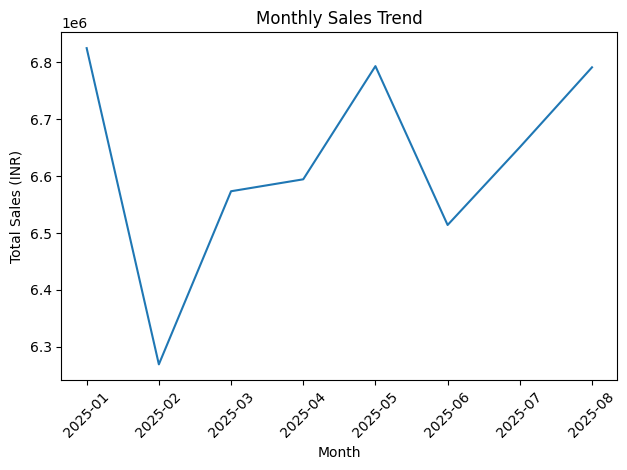

In [19]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['YearMonth']=df['Order Date'].dt.to_period('M').astype(str)
monthly_sales=df.groupby('YearMonth')['Price (INR)'].sum().reset_index()
plt.figure()
plt.plot(monthly_sales['YearMonth'],monthly_sales['Price (INR)'])
plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Total Sales (INR)')
plt.title('Monthly Sales Trend')
plt.tight_layout()
plt.show()

####Daily Sales Trend

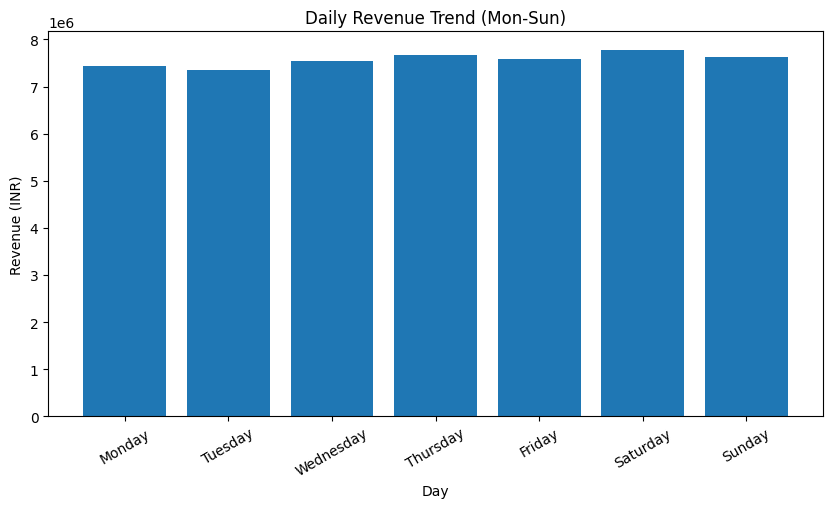

In [20]:
df['DayName']=pd.to_datetime(df['Order Date']).dt.day_name()
daily_revenue=(df.groupby('DayName')['Price (INR)'].sum().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]))
plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index,daily_revenue.values)
plt.title("Daily Revenue Trend (Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)
plt.show()

####Total Sales by Food Type(Veg vs Non-Veg)

In [21]:
non_veg_keywords=[
    "chicken","egg","fish","mutton","prawn",
    "biryani","kabab","kebab","non-veg","non veg"
    ]
df["Food Category"]=np.where(
    df["Dish Name"].str.lower().str.contains('|'.join(non_veg_keywords),na=False),
    "Non-Veg","Veg")

In [22]:
food_revenue=(
    df.groupby("Food Category")["Price (INR)"].sum().reset_index()
)

In [23]:
fig=px.pie(food_revenue,values="Price (INR)",names="Food Category",hole=0.5,title="Revenue Contribution: Veg vs Non-Veg")
fig.update_traces(textinfo='percent+label',pull=[0.05,0])
fig.update_layout(height=500,margin=dict(t=60,b=40,l=40,r=40))
fig.show()

####Total Sales by State

In [24]:
fig=px.bar(df.groupby("State",as_index=False)["Price (INR)"].sum()
.sort_values(by="Price (INR)",ascending=False),
x="Price (INR)",y="State",orientation="h",
           title="Revenue by State (INR)")
fig.update_layout(height=600,yaxis=dict(autorange="reversed"))
fig.show()

####Quarterly Performance Summary

In [26]:
df['Order_Date']=pd.to_datetime(df['Order Date'])
df['Quarter']=df['Order_Date'].dt.to_period('Q').astype(str)
quartely_summary=(
    df.groupby('Quarter',as_index=False)
    .agg(Total_Sales=('Price (INR)','sum'),
         Avg_Rating=('Rating','mean'),
         Total_Orders=('Order_Date','count')
)
.sort_values('Quarter')
)
quartely_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667821.77,4.342643,73096
1,2025Q2,19902256.59,4.340011,74163
2,2025Q3,13442427.41,4.342359,50171


####Top 5 Cities by Sales

In [28]:
top_5_cities=(
    df.groupby('City')['Price (INR)'].sum().nlargest(5).sort_values().reset_index()
)
fig=px.bar(
    top_5_cities,x='Price (INR)',y='City',orientation='h',
    title='Top 5 Cities by Sales (INR)',color_discrete_sequence=['red']
)
fig.show()

####Weekly Trend Analysis

Weekly Sales Trend:
Order Date
2025-01-05    1101057.42
2025-01-12    1543434.40
2025-01-19    1512362.20
2025-01-26    1540131.11
2025-02-02    1549636.81
2025-02-09    1517261.95
2025-02-16    1560241.45
2025-02-23    1697992.73
2025-03-02    1491166.47
2025-03-09    1472957.58
2025-03-16    1432734.17
2025-03-23    1532189.59
2025-03-30    1505209.46
2025-04-06    1504614.95
2025-04-13    1551114.39
2025-04-20    1544439.18
2025-04-27    1535155.98
2025-05-04    1538323.77
2025-05-11    1510560.18
2025-05-18    1522188.84
2025-05-25    1563458.34
2025-06-01    1529227.72
2025-06-08    1512160.24
2025-06-15    1530811.30
2025-06-22    1545937.96
2025-06-29    1512116.42
2025-07-06    1539434.79
2025-07-13    1512554.39
2025-07-20    1456760.95
2025-07-27    1501031.76
2025-08-03    1535617.47
2025-08-10    1558098.72
2025-08-17    1497733.59
2025-08-24    1548112.71
2025-08-31    1506676.78
Freq: W-SUN, Name: Price (INR), dtype: float64


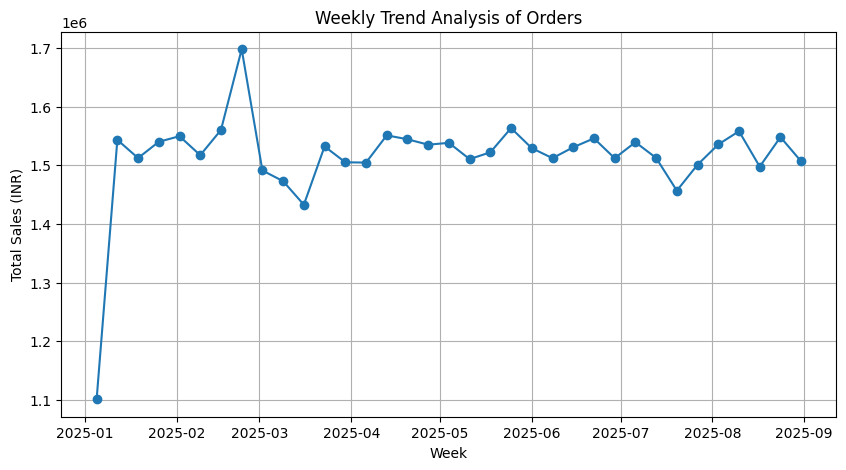

In [31]:
# Convert Order Date column to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Set Order Date as index
df.set_index('Order Date', inplace=True)

# Weekly trend based on Price (INR)
weekly_trend = df['Price (INR)'].resample('W').sum()

print("Weekly Sales Trend:")
print(weekly_trend)

# Plot weekly trend
plt.figure(figsize=(10,5))
plt.plot(weekly_trend.index, weekly_trend.values, marker='o')
plt.title("Weekly Trend Analysis of Orders")
plt.xlabel("Week")
plt.ylabel("Total Sales (INR)")
plt.grid(True)
plt.show()